#  <center> Speech Emotion Recognition <center>

# Importing Libraries

In [2]:
!apt-get update
!apt-get install -y -q libsndfile1

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,086 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,817 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,398 kB] 
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-back

In [3]:
!pip install praat-parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 99.6 MB/s eta 0:00:00:00:01:01


In [ ]:

# librosa is a Python library for analyzing audio and music. It can be used to extract the data from the audio files we will see it later.
import librosa
import pandas as pd
import numpy as np
import os
import sys

# to play the audio files
from IPython.display import Audio

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

## Data Preparation
* As we are working with four different datasets, so i will be creating a dataframe storing all emotions of the data in dataframe with their paths.
* We will use this dataframe to extract features for our model training.

In [80]:
# Paths for data.
RAVDESS = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
CREMA = "/kaggle/input/cremad/AudioWAV/"
TESS = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"
SAVEE = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"

##  <center> 1. Ravdess Dataframe <center>
Here is the filename identifiers as per the official RAVDESS website:

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

So, here's an example of an audio filename. 02-01-06-01-02-01-12.mp4
This means the meta data for the audio file is:

* Video-only (02)
* Speech (01)
* Fearful (06)
* Normal intensity (01)
* Statement "dogs" (02)
* 1st Repetition (01)
* 12th Actor (12) - Female (as the actor ID number is even)

In [81]:
dir_list = os.listdir(RAVDESS)
dir_list.sort()

emotion = []
gender = []
path = []
for i in dir_list:
    if i == 'audio_speech_actors_01-24':
        break
    fname = os.listdir(RAVDESS + i)
    for f in fname:
        part = f.split('.')[0].split('-')
        #print(part[2])
        emotion.append(int(part[2]))
        temp = int(part[6])
        if temp%2 == 0:
            temp = "female"
        else:
            temp = "male"
        gender.append(temp)
        path.append(RAVDESS + i + '/' + f)

        
Ravdess_df = pd.DataFrame(emotion)
Ravdess_df = Ravdess_df.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'})
Ravdess_df = pd.concat([pd.DataFrame(gender),Ravdess_df],axis=1)
Ravdess_df.columns = ['gender','emotion']
Ravdess_df['labels'] =Ravdess_df.gender + '_' + Ravdess_df.emotion
Ravdess_df['source'] = 'RAVDESS'  
Ravdess_df = pd.concat([Ravdess_df,pd.DataFrame(path, columns = ['path'])],axis=1)
Ravdess_df = Ravdess_df.drop(['gender', 'emotion'], axis=1)
Ravdess_df.labels.value_counts()

labels
male_calm          96
male_sad           96
male_fear          96
male_happy         96
male_angry         96
male_disgust       96
male_surprise      96
female_surprise    96
female_happy       96
female_disgust     96
female_fear        96
female_sad         96
female_angry       96
female_calm        96
male_neutral       48
female_neutral     48
Name: count, dtype: int64

## <center>2. Crema DataFrame</center>

In [82]:
dir_list = os.listdir(CREMA)
dir_list.sort()
gender = []
emotion = []
path = []
female = [1002,1003,1004,1006,1007,1008,1009,1010,1012,1013,1018,1020,1021,1024,1025,1028,1029,1030,1037,1043,1046,1047,1049,
          1052,1053,1054,1055,1056,1058,1060,1061,1063,1072,1073,1074,1075,1076,1078,1079,1082,1084,1089,1091]

for i in dir_list: 
    part = i.split('_')
    if int(part[0]) in female:
        temp = 'female'
    else:
        temp = 'male'
    gender.append(temp)
    if part[2] == 'SAD' and temp == 'male':
        emotion.append('male_sad')
    elif part[2] == 'ANG' and temp == 'male':
        emotion.append('male_angry')
    elif part[2] == 'DIS' and temp == 'male':
        emotion.append('male_disgust')
    elif part[2] == 'FEA' and temp == 'male':
        emotion.append('male_fear')
    elif part[2] == 'HAP' and temp == 'male':
        emotion.append('male_happy')
    elif part[2] == 'NEU' and temp == 'male':
        emotion.append('male_neutral')
    elif part[2] == 'SAD' and temp == 'female':
        emotion.append('female_sad')
    elif part[2] == 'ANG' and temp == 'female':
        emotion.append('female_angry')
    elif part[2] == 'DIS' and temp == 'female':
        emotion.append('female_disgust')
    elif part[2] == 'FEA' and temp == 'female':
        emotion.append('female_fear')
    elif part[2] == 'HAP' and temp == 'female':
        emotion.append('female_happy')
    elif part[2] == 'NEU' and temp == 'female':
        emotion.append('female_neutral')
    else:
        emotion.append('Unknown')
    path.append(CREMA + i)
    
CREMA_df = pd.DataFrame(emotion, columns = ['labels'])
CREMA_df['source'] = 'CREMA'
CREMA_df = pd.concat([CREMA_df,pd.DataFrame(path, columns = ['path'])],axis=1)
CREMA_df.labels.value_counts()

labels
male_angry        671
male_disgust      671
male_fear         671
male_happy        671
male_sad          671
female_angry      600
female_disgust    600
female_fear       600
female_sad        600
female_happy      600
male_neutral      575
female_neutral    512
Name: count, dtype: int64

##  <center> 3. TESS dataset <center>

In [83]:
dir_list = os.listdir(TESS)

path = []
emotion = []

for i in dir_list:
    fname = os.listdir(TESS + i)
    for f in fname:
        if i == 'OAF_angry' or i == 'YAF_angry':
            emotion.append('female_angry')
        elif i == 'OAF_disgust' or i == 'YAF_disgust':
            emotion.append('female_disgust')
        elif i == 'OAF_Fear' or i == 'YAF_fear':
            emotion.append('female_fear')
        elif i == 'OAF_happy' or i == 'YAF_happy':
            emotion.append('female_happy')
        elif i == 'OAF_neutral' or i == 'YAF_neutral':
            emotion.append('female_neutral')                                
        elif i == 'OAF_Pleasant_surprise' or i == 'YAF_pleasant_surprised':
            emotion.append('female_surprise')               
        elif i == 'OAF_Sad' or i == 'YAF_sad':
            emotion.append('female_sad')
        else:
            emotion.append('Unknown')
        path.append(TESS + i + "/" + f)

TESS_df = pd.DataFrame(emotion, columns = ['labels'])
TESS_df['source'] = 'TESS'
TESS_df = pd.concat([TESS_df,pd.DataFrame(path, columns = ['path'])],axis=1)
TESS_df.labels.value_counts()

labels
female_fear        400
female_angry       400
female_disgust     400
female_neutral     400
female_sad         400
female_surprise    400
female_happy       400
Name: count, dtype: int64

##  <center> 4. CREMA-D dataset <center>
The audio files in this dataset are named in such a way that the prefix letters describes the emotion classes as follows:

* 'a' = 'anger'
* 'd' = 'disgust'
* 'f' = 'fear'
* 'h' = 'happiness'
* 'n' = 'neutral'
* 'sa' = 'sadness'
* 'su' = 'surprise'

In [84]:
dir_list = os.listdir(SAVEE)

emotion=[]
path = []
for i in dir_list:
    if i[-8:-6]=='_a':
        emotion.append('male_angry')
    elif i[-8:-6]=='_d':
        emotion.append('male_disgust')
    elif i[-8:-6]=='_f':
        emotion.append('male_fear')
    elif i[-8:-6]=='_h':
        emotion.append('male_happy')
    elif i[-8:-6]=='_n':
        emotion.append('male_neutral')
    elif i[-8:-6]=='sa':
        emotion.append('male_sad')
    elif i[-8:-6]=='su':
        emotion.append('male_surprise')
    else:
        emotion.append('male_error') 
    path.append(SAVEE + i)
    
SAVEE_df = pd.DataFrame(emotion, columns = ['labels'])
SAVEE_df['source'] = 'SAVEE'
SAVEE_df = pd.concat([SAVEE_df, pd.DataFrame(path, columns = ['path'])], axis = 1)
SAVEE_df.labels.value_counts()

labels
male_neutral     120
male_fear         60
male_happy        60
male_disgust      60
male_angry        60
male_surprise     60
male_sad          60
Name: count, dtype: int64

In [85]:
# creating Dataframe using all the 4 dataframes we created so far.
data_path = pd.concat([Ravdess_df, CREMA_df, TESS_df, SAVEE_df], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,labels,source,path
0,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
1,male_neutral,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
2,male_sad,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
3,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
4,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...


In [ ]:
data_path.to_csv("new_data_path.csv",index=False)
print(len(data_path))
data_path.head()

11682


,labels,source,path
0,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
1,male_neutral,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
2,male_sad,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
3,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
4,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...


In [88]:
# read data frame and make sure that each index has one record not 4
data_path = pd.read_csv('/kaggle/working/new_data_path.csv')
data_path

,labels,source,path
0,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
1,male_neutral,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
2,male_sad,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
3,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
4,male_calm,RAVDESS,/kaggle/input/ravdess-emotional-speech-audio/a...
...,...,...,...
11677,female_surprise,TESS,/kaggle/input/toronto-emotional-speech-set-tes...
11678,female_surprise,TESS,/kaggle/input/toronto-emotional-speech-set-tes...
11679,female_surprise,TESS,/kaggle/input/toronto-emotional-speech-set-tes...
11680,female_surprise,TESS,/kaggle/input/toronto-emotional-speech-set-tes...


In [39]:
data_path.labels.value_counts()

labels
female_sad         1096
female_happy       1096
female_disgust     1096
female_angry       1096
female_fear        1096
female_neutral      960
male_fear           767
male_sad            767
male_happy          767
male_disgust        767
male_angry          767
male_neutral        623
female_surprise     496
male_calm            96
male_surprise        96
female_calm          96
Name: count, dtype: int64

## EDA


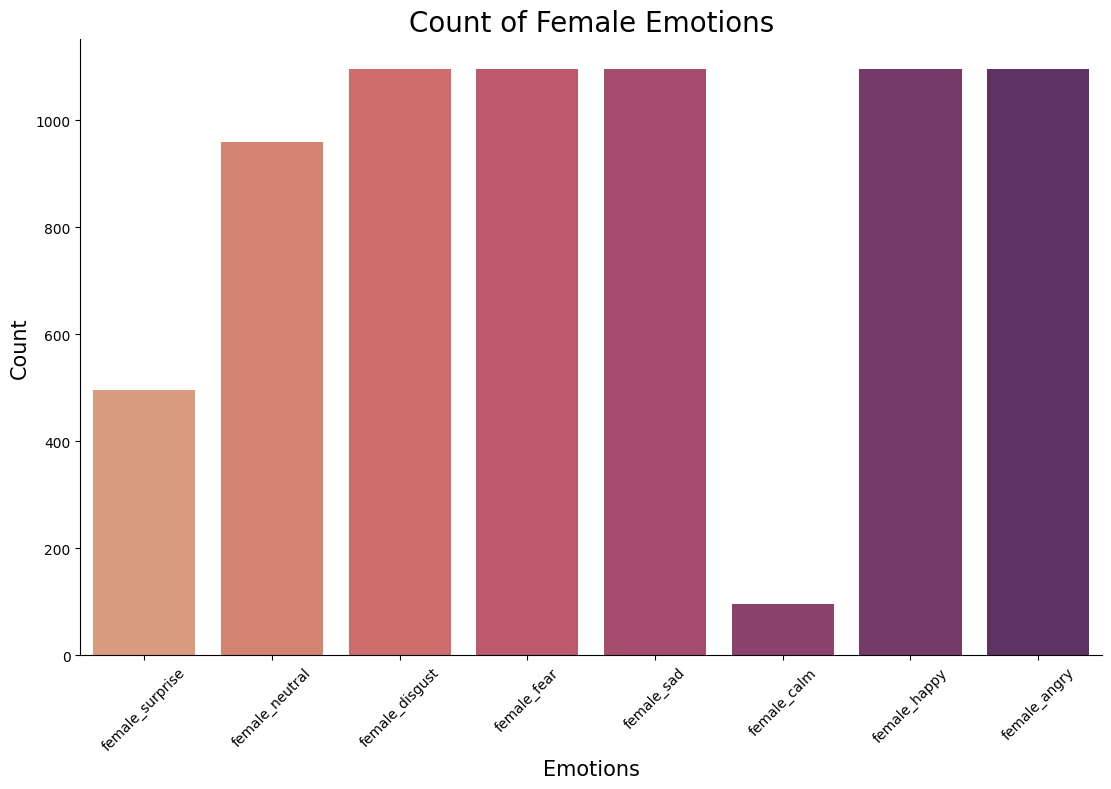

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Separate male and female emotion labels
female_data = data_path[data_path['labels'].str.startswith('female')]
male_data = data_path[data_path['labels'].str.startswith('male')]

# Create figure with two subplots side by side
plt.figure(figsize=(29, 8))

# Female emotions
plt.subplot(1, 2, 2)
sns.countplot(x=female_data['labels'], palette='flare')
plt.title('Count of Female Emotions', size=20)
plt.ylabel('Count', size=15)
plt.xlabel('Emotions', size=15)
plt.xticks(rotation=45)
sns.despine(top=True, right=True, left=False, bottom=False)




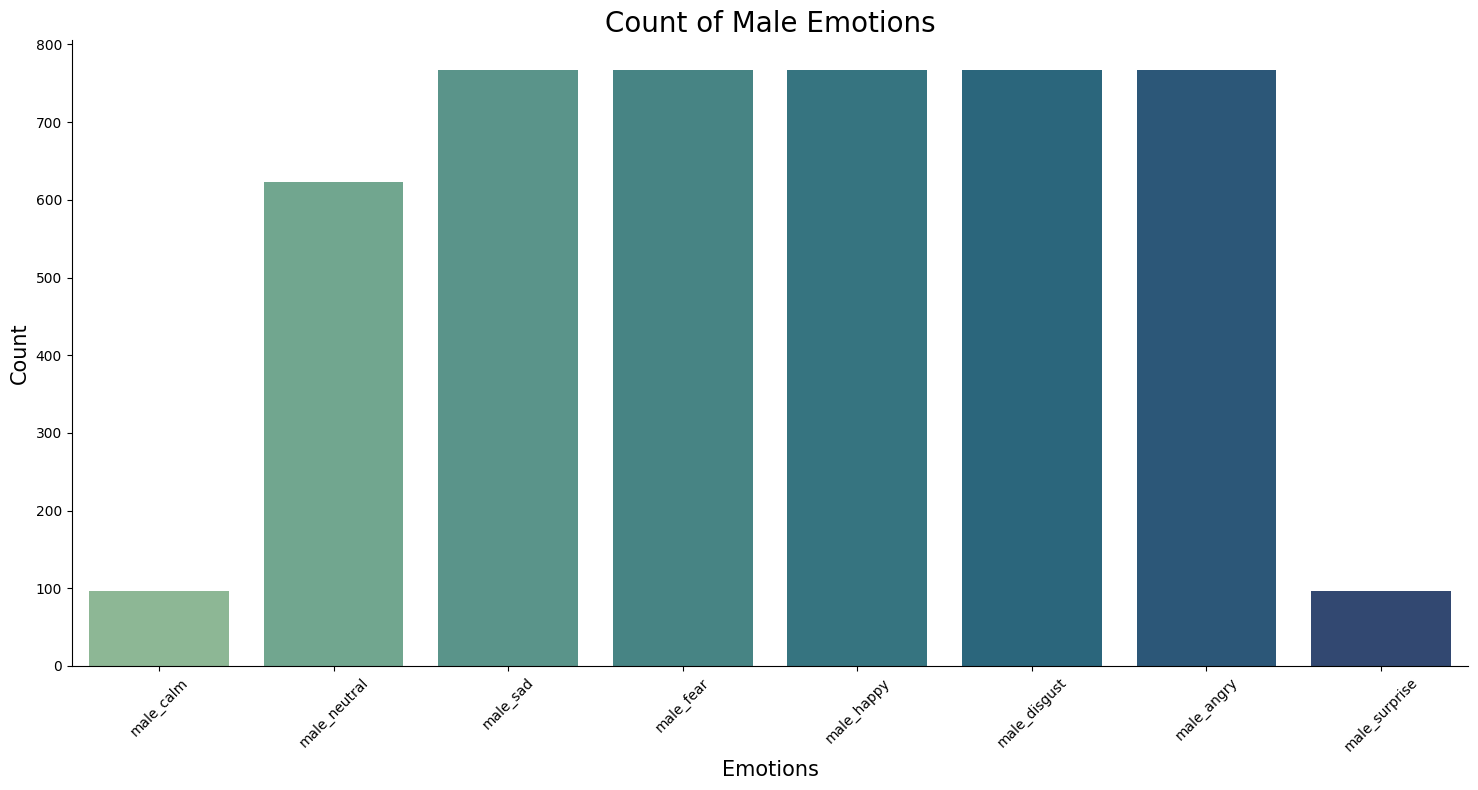

In [96]:
# Create figure with two subplots side by side
plt.figure(figsize=(29, 8))
# Male emotions
plt.subplot(1, 2, 2)
sns.countplot(x=male_data['labels'], palette='crest')
plt.title('Count of Male Emotions', size=20)
plt.ylabel('Count', size=15)
plt.xlabel('Emotions', size=15)
plt.xticks(rotation=45)
sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

In [ ]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveplot(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

In [ ]:
emotion='calm'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='neutral'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='sad'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='happy'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

## Augmentation



In [100]:
def noise(data):
    noise_amp = 0.04*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.70):
    return librosa.effects.time_stretch(data,rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

def higher_speed(data, speed_factor = 1.25):
    return librosa.effects.time_stretch(data,rate=speed_factor)

def lower_speed(data, speed_factor = 0.75):
    return librosa.effects.time_stretch(data,rate=speed_factor)

In [45]:
import numpy as np
import librosa
import random

def prosody_warp(data, sample_rate, emotion=None, num_segments=3):
    """
    Emotion-aware prosody warping augmentation for short emotional clips.
    Keeps pitch/rate change subtle but emotion-sensitive.
    """

    # Base limits — scaled by emotion
    emotion_settings = {
        "angry":   (2.0, 0.20),  # stronger warp
        "happy":   (2.0, 0.20),
        "surprise":(2.5, 0.25),
        "sad":     (1.0, 0.10),
        "calm":    (0.8, 0.08),
        "neutral": (1.0, 0.10),
        "fear":    (1.5, 0.15),
        "disgust": (1.2, 0.12)
    }

    # Get appropriate scaling
    max_pitch_shift, max_rate_change = emotion_settings.get(emotion, (1.5, 0.15))

    warped = np.copy(data)
    length = len(data)
    segment_len = length // (num_segments + 1)

    for _ in range(num_segments):
        start = random.randint(0, length - segment_len)
        end = start + segment_len // random.randint(2, 4)
        segment = warped[start:end]

        pitch_shift = random.uniform(-max_pitch_shift, max_pitch_shift)
        rate = 1.0 + random.uniform(-max_rate_change, max_rate_change)

        warped_segment = librosa.effects.pitch_shift(segment, sr=sample_rate, n_steps=pitch_shift)
        D = librosa.stft(warped_segment)
        D_stretched = librosa.phase_vocoder(D, rate=rate)
        warped_segment = librosa.istft(D_stretched, length=len(warped_segment))
        warped_segment = librosa.util.fix_length(warped_segment, size=end - start)

        warped[start:end] = warped_segment

    return warped


In [121]:
import matplotlib.pyplot as plt
import librosa.display

def _plot_signal_and_augmented_signal(signal, augmented_signal, sr):
    fig, ax = plt.subplots(nrows=2, figsize=(12, 6))  # wider and taller figure
    librosa.display.waveshow(signal, sr=sr, ax=ax[0])
    ax[0].set_title('Original Signal', fontsize=12)
    
    librosa.display.waveshow(augmented_signal, sr=sr, ax=ax[1])
    ax[1].set_title('Augmented Signal', fontsize=12)
    
    plt.tight_layout(pad=2.0)  # add space between subplots
    plt.show()


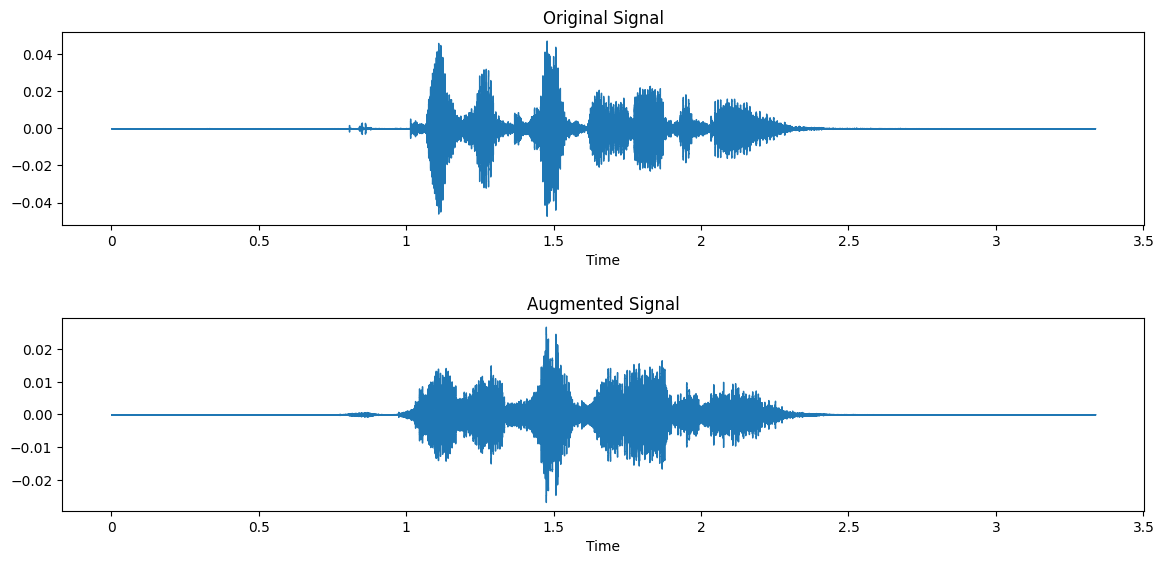

In [123]:
path = np.array(data_path.path)[1]
data, sr = librosa.load(path)
augmented_signal = pitch(data,sr)
_plot_signal_and_augmented_signal(data, augmented_signal, sr)

In [28]:
import random
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# taking any example and checking for techniques.
# Suppose the column is 'path'
path = data_path['path'].iloc[1]  # gets the second row

data, sample_rate = librosa.load(path)

#### 1. Normal

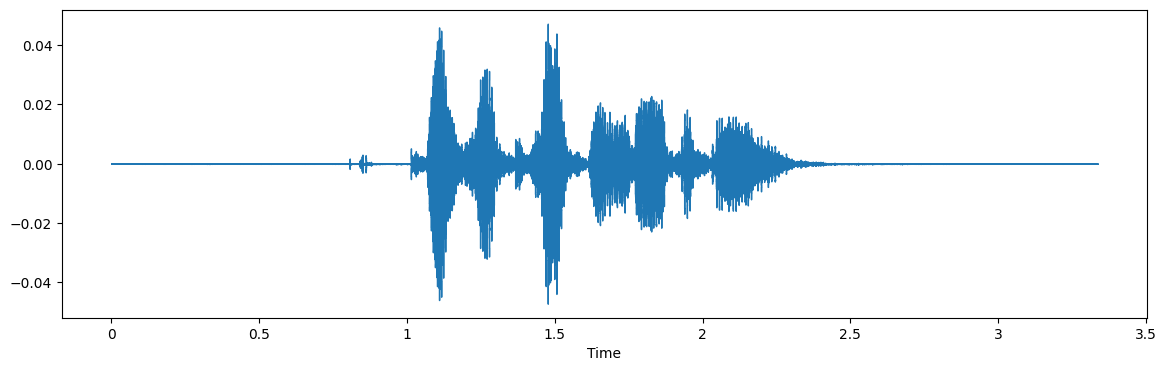

In [29]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

#### 2. Noise

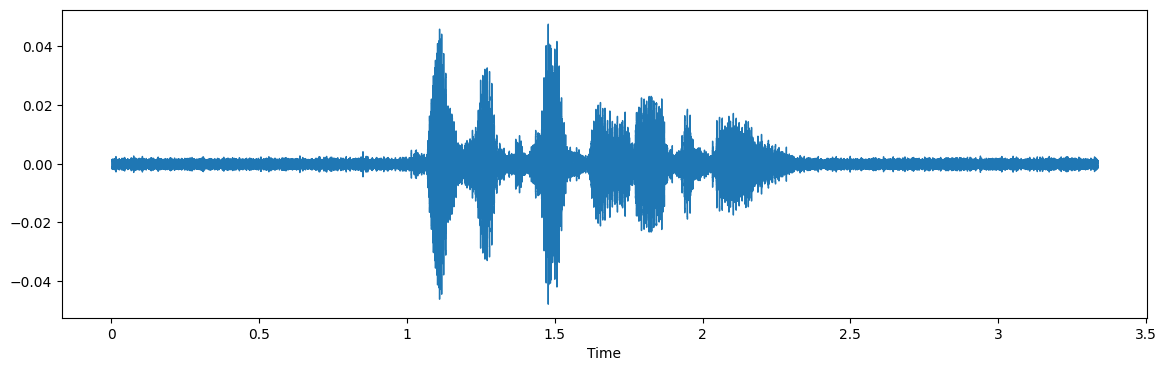

In [30]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

We can see noise injection is a very good augmentation technique because of which we can assure our training model is not overfitted

#### 3. Stretch

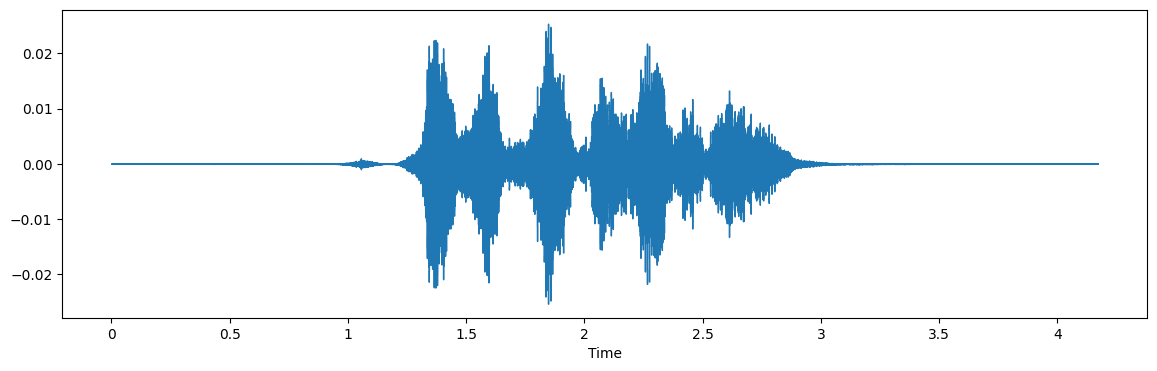

In [31]:
x = stretch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)


#### 4. Shift

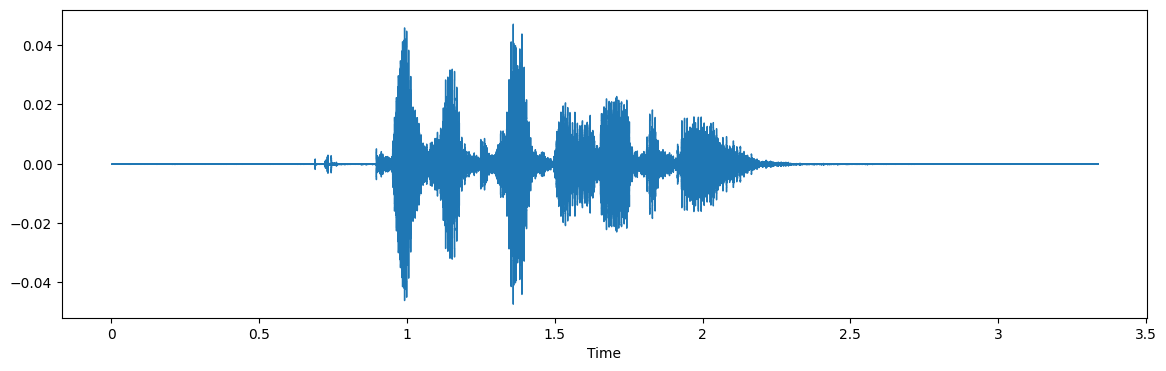

In [32]:
x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

#### 5. Pitch

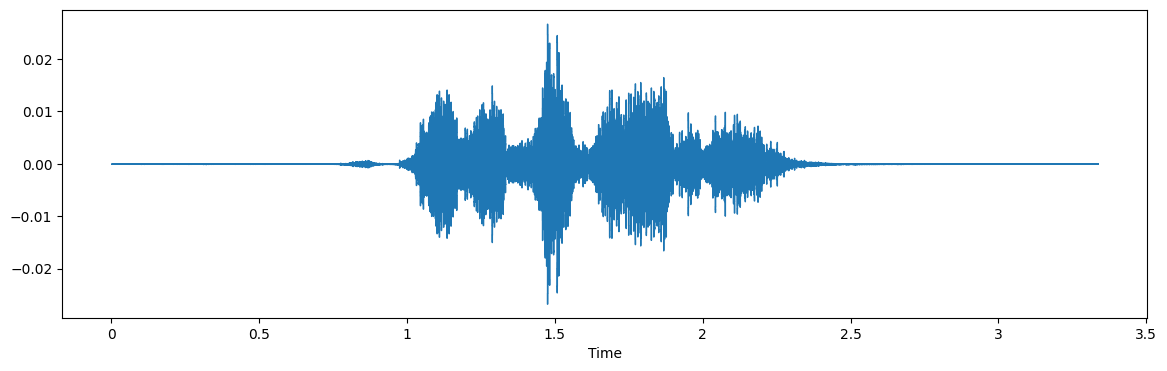

In [33]:
x = pitch(data, sample_rate)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

#### 6. Higher Speed

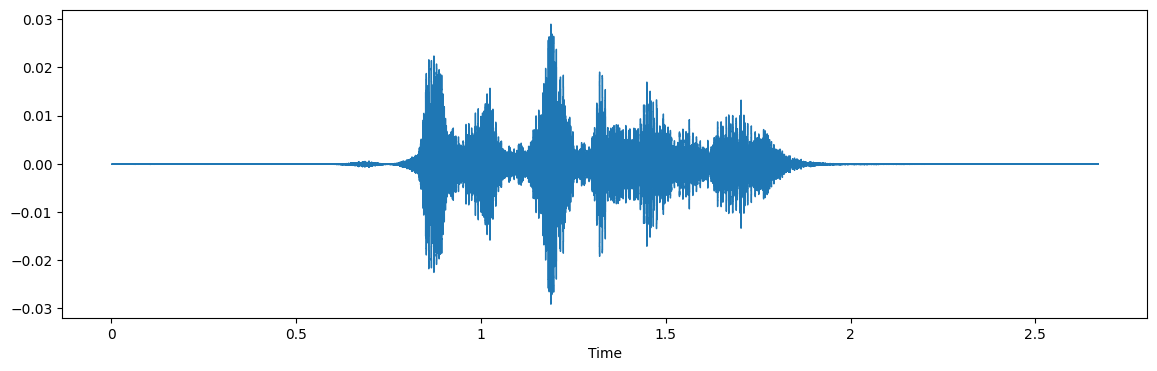

In [34]:
x = higher_speed(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)


#### 7. Lower speed

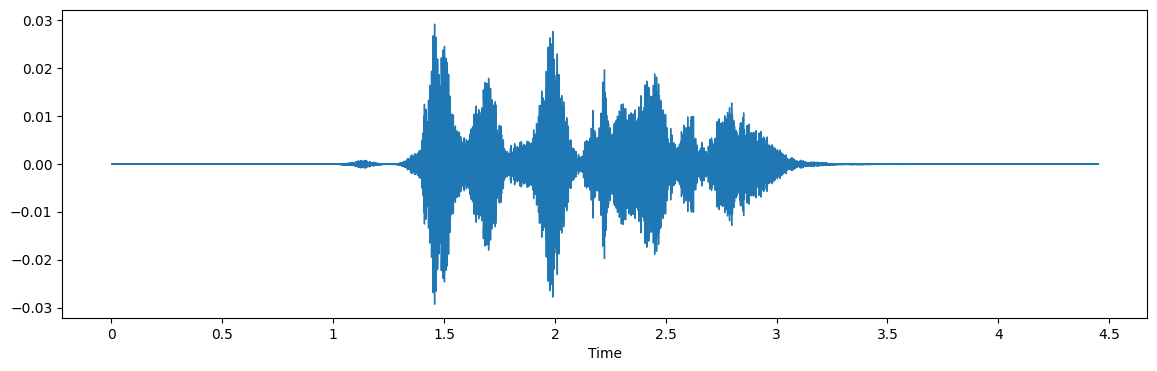

In [35]:
x = lower_speed(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)


#### 8. Prosody warp

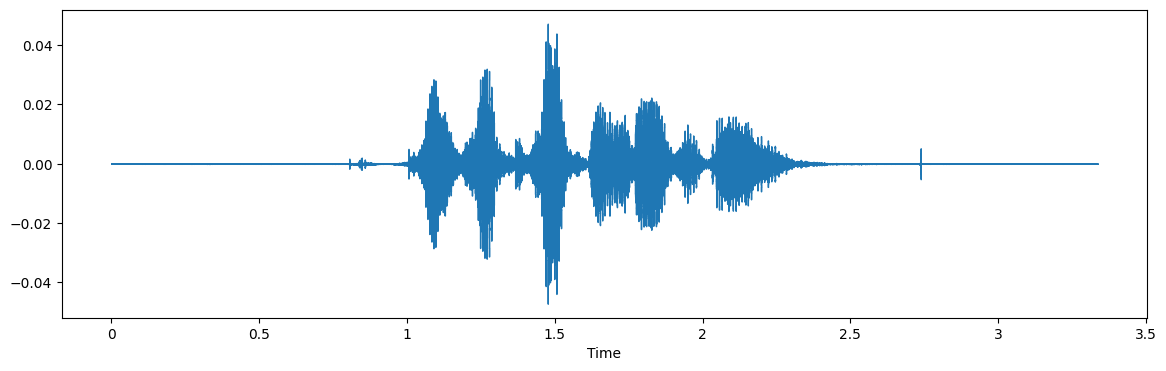

In [36]:
prosody_data = prosody_warp(data, sample_rate)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=prosody_data, sr=sample_rate)
Audio(prosody_data, rate=sample_rate)

In [ ]:
print(sample_rate)

In [46]:
import numpy as np
import librosa
import random

# sample_rate = 22050

def extract_features(data):
    """
    Extract MFCC + Delta + Delta-Delta features, averaged over time.
    """
    # Compute base MFCCs
    mfccs = librosa.feature.mfcc(y=data, sr=22050, n_mfcc=58)
    
    # Compute first and second derivatives
    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)
    
    # Stack features: [MFCC, Delta, Delta-Delta]
    combined = np.vstack([mfccs, delta, delta2])
    
    # Take the mean over time axis
    combined_processed = np.mean(combined.T, axis=0)
    
    return np.array(combined_processed)


In [47]:
def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=3, offset=0.5) 
    
    #without augmentation
    res1 = extract_features(data)
    result = np.array(res1)
    
    #noised
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    
    #stretched
    stretch_data = stretch(data)
    res3 = extract_features(stretch_data)
    result = np.vstack((result, res3))
    
    #shifted
    shift_data = shift(data)
    res4 = extract_features(shift_data)
    result = np.vstack((result, res4))
    
    #pitched
    pitch_data = pitch(data, sample_rate)
    res5 = extract_features(pitch_data)
    result = np.vstack((result, res5)) 
    
    #speed up
    higher_speed_data = higher_speed(data)
    res6 = extract_features(higher_speed_data)
    result = np.vstack((result, res6))
    
    #speed down
    lower_speed_data = lower_speed(data)
    res7 = extract_features(lower_speed_data)
    result = np.vstack((result, res7))

    # prosody-warped
    prosody_data = prosody_warp(data, sample_rate)
    res8 = extract_features(prosody_data)
    result = np.vstack((result, res8))
    
        
    return result

In [142]:
len(data_path)

454

In [48]:
import time
start_time = time.time()
X, Y = [], []

for path, emotion in zip(data_path.path, data_path.labels):
    features = get_features(path)
    for feature in features:
        X.append(feature)
        # appending emotion 5 times as we have made 5 augmentation techniques on each audio file.
        Y.append(emotion)

end_time = time.time()
print(f"Preprocessing time: {end_time - start_time:.3f} seconds")

Preprocessing time: 1723.795 seconds


In [ ]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head(5)

,0,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,labels
0,-667.117126,79.265198,0.214563,14.969451,8.738843,1.614774,-1.532765,-7.318048,-9.807106,-5.784626,...,-0.000766,-0.005936,-0.001535,-0.004762,-0.001679,-0.003192,-0.000871,-0.001724,0.000710,male_calm
1,-545.048045,51.426837,6.064574,10.204019,5.760394,1.223468,-3.169587,-8.223262,-9.309216,-5.427679,...,-0.004012,-0.017364,-0.005247,-0.015410,0.013281,0.052806,0.024740,-0.001587,0.014429,male_calm
2,-687.362854,75.290314,-1.210313,14.314181,8.129524,0.945774,-2.258049,-8.516194,-10.246472,-6.361132,...,-0.000327,-0.000344,-0.000354,-0.000358,-0.000355,-0.000347,-0.000333,-0.000314,-0.000291,male_calm
3,-666.793945,79.154823,0.106053,14.941360,8.781667,1.504403,-1.560568,-7.424084,-9.807270,-5.694724,...,-0.002193,0.001984,-0.001488,0.001359,-0.000960,0.000925,-0.000633,0.001021,-0.000398,male_calm
4,-693.085571,76.648880,-2.235752,15.661763,6.219833,0.362050,-5.023973,-10.431779,-11.020194,-4.200662,...,-0.001277,-0.004627,0.000215,-0.004181,0.001625,-0.003115,0.002478,-0.001823,0.002685,male_calm
